# Snapshot Wisconsin: One-by-One Validation

This notebook loads the trained model and checks individual deer images.
It compares the model prediction with the label in the CSV file.

Run the cells from top to bottom. No training is performed here.

## 1. Configuration

In [6]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

ROOT = Path.cwd()
CSV_PATH = ROOT / 'Snapshot_WI-Oh_Deer_data-v1.csv'
PHOTOS_DIR = ROOT / 'Snapshot_WI-Oh_Deer_Photos' / 'Deer'
MODEL_PATH = ROOT / 'oh_deer_model.pt'
DEVICE = torch.device('cpu')
RANDOM_SEED = 42
NUMBER_OF_RANDOM_IMAGES = 12

print('Working directory:', ROOT)
print('Model:', MODEL_PATH)
print('Device:', DEVICE)

Working directory: d:\电子教材\UWM\Snapshot
Model: d:\电子教材\UWM\Snapshot\oh_deer_model.pt
Device: cpu


## 2. Load the CSV and trained model

In [7]:
df = pd.read_csv(CSV_PATH)

def normalize_label(value, positive_keys, negative_keys):
    text = str(value).strip().lower()
    if any(key in text for key in positive_keys):
        return 1
    if any(key in text for key in negative_keys):
        return 0
    return None

df['true_antler'] = df['antler_status'].map(
    lambda value: normalize_label(value, ['antlered', 'yes', 'true', 'buck'], ['antlerless', 'no', 'false', 'doe'])
)
df['true_age'] = df['age_status'].map(
    lambda value: normalize_label(value, ['young', 'fawn', 'juvenile'], ['adult', 'mature'])
)
df = df.dropna(subset=['true_antler', 'true_age']).reset_index(drop=True)
df['true_antler'] = df['true_antler'].astype(int)
df['true_age'] = df['true_age'].astype(int)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
MODEL_NAME = checkpoint.get('model_name', 'efficientnet_b0')
IMG_SIZE = int(checkpoint.get('img_size', 224))
THRESHOLD_ANTLER = float(checkpoint.get('threshold_antler', 0.5))
THRESHOLD_AGE = float(checkpoint.get('threshold_age', 0.5))

print('Rows in CSV:', len(df))
print('Model:', MODEL_NAME)
print('Image size:', IMG_SIZE)
print('Thresholds:', THRESHOLD_ANTLER, THRESHOLD_AGE)

Rows in CSV: 4880
Model: efficientnet_b0
Image size: 224
Thresholds: 0.5 0.5


In [8]:
class MultiTaskDeer(nn.Module):
    def __init__(self, backbone='efficientnet_b0'):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=False, num_classes=0, global_pool='avg'
        )
        features = self.backbone.num_features
        self.dropout = nn.Dropout(0.3)
        self.head_antler = nn.Linear(features, 2)
        self.head_age = nn.Linear(features, 2)

    def forward(self, x):
        features = self.dropout(self.backbone(x))
        return self.head_antler(features), self.head_age(features)

model = MultiTaskDeer(MODEL_NAME).to(DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print('Model loaded successfully.')

Model loaded successfully.


## 3. Single-image prediction

In [9]:
def image_path(filename):
    return PHOTOS_DIR / str(filename)

@torch.no_grad()
def predict_one(row_or_filename):
    if isinstance(row_or_filename, str):
        row = df.loc[df['filename'].eq(row_or_filename)].iloc[0]
    else:
        row = row_or_filename
    path = image_path(row['filename'])
    image = Image.open(path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(DEVICE)
    antler_logits, age_logits = model(tensor)
    antler_probability = float(antler_logits.softmax(1)[0, 1])
    age_probability = float(age_logits.softmax(1)[0, 1])
    prediction = {
        'filename': row['filename'],
        'true_antler': 'Antlered' if row['true_antler'] else 'Antlerless',
        'pred_antler': 'Antlered' if antler_probability > THRESHOLD_ANTLER else 'Antlerless',
        'antler_probability': antler_probability,
        'true_age': 'Young' if row['true_age'] else 'Adult',
        'pred_age': 'Young' if age_probability > THRESHOLD_AGE else 'Adult',
        'age_probability': age_probability,
        'image_path': str(path),
    }
    return prediction, image

def show_prediction(row_or_filename):
    result, image = predict_one(row_or_filename)
    antler_ok = result['true_antler'] == result['pred_antler']
    age_ok = result['true_age'] == result['pred_age']
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(
        f"Antlers: true={result['true_antler']} | pred={result['pred_antler']} ({'OK' if antler_ok else 'WRONG'})\n"
        f"Age: true={result['true_age']} | pred={result['pred_age']} ({'OK' if age_ok else 'WRONG'})"
    )
    plt.show()
    print(pd.Series(result).drop('image_path').to_string())
    return result

## 4. Test one random image

Run this cell whenever you want another random single-image check.

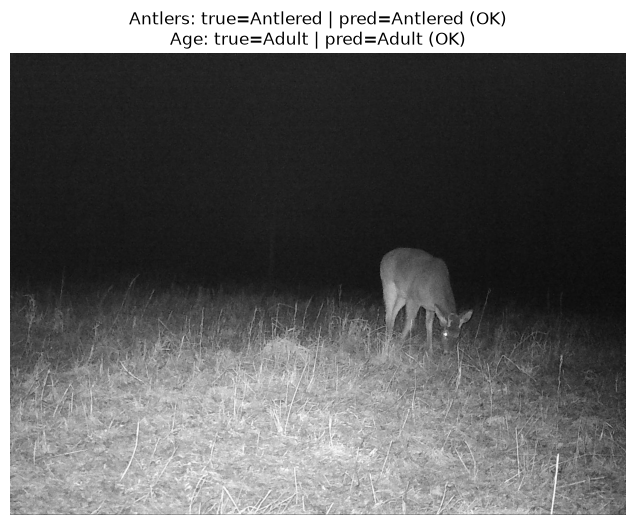

filename              SSWI000000024756558A.jpg
true_antler                           Antlered
pred_antler                           Antlered
antler_probability                    0.966669
true_age                                 Adult
pred_age                                 Adult
age_probability                       0.065347


In [49]:
random_row = df.sample(1, random_state=random.randint(0, 100000)).iloc[0]
one_result = show_prediction(random_row)

## 5. Test several random images

This creates a small manual validation set and summarizes the results.

Antler accuracy: 75.0%
Age accuracy: 91.7%


,filename,true_antler,pred_antler,antler_probability,true_age,pred_age,age_probability,antler_correct,age_correct
0,SSWI000000010476124C.jpg,Antlerless,Antlerless,0.448086,Young,Adult,0.411359,True,False
1,SSWI000000021879806A.jpg,Antlerless,Antlerless,0.040250,Adult,Adult,0.043901,True,True
2,SSWI000000023785430C.jpg,Antlered,Antlered,0.812095,Adult,Adult,0.140500,True,True
3,SSWI000000009875545A.jpg,Antlerless,Antlered,0.836824,Adult,Adult,0.188489,False,True
4,SSWI000000010847107B.jpg,Antlerless,Antlered,0.962060,Adult,Adult,0.105228,False,True
5,SSWI000000030158981B.jpg,Antlerless,Antlerless,0.196350,Adult,Adult,0.346122,True,True
6,SSWI000000013080500C.jpg,Antlerless,Antlered,0.866397,Adult,Adult,0.114814,False,True
7,SSWI000000021295110B.jpg,Antlered,Antlered,0.941352,Adult,Adult,0.117798,True,True
8,SSWI000000025354012B.jpg,Antlerless,Antlerless,0.045907,Adult,Adult,0.475128,True,True
9,SSWI000000011340926C.jpg,Antlerless,Antlerless,0.054837,Young,Young,0.978014,True,True


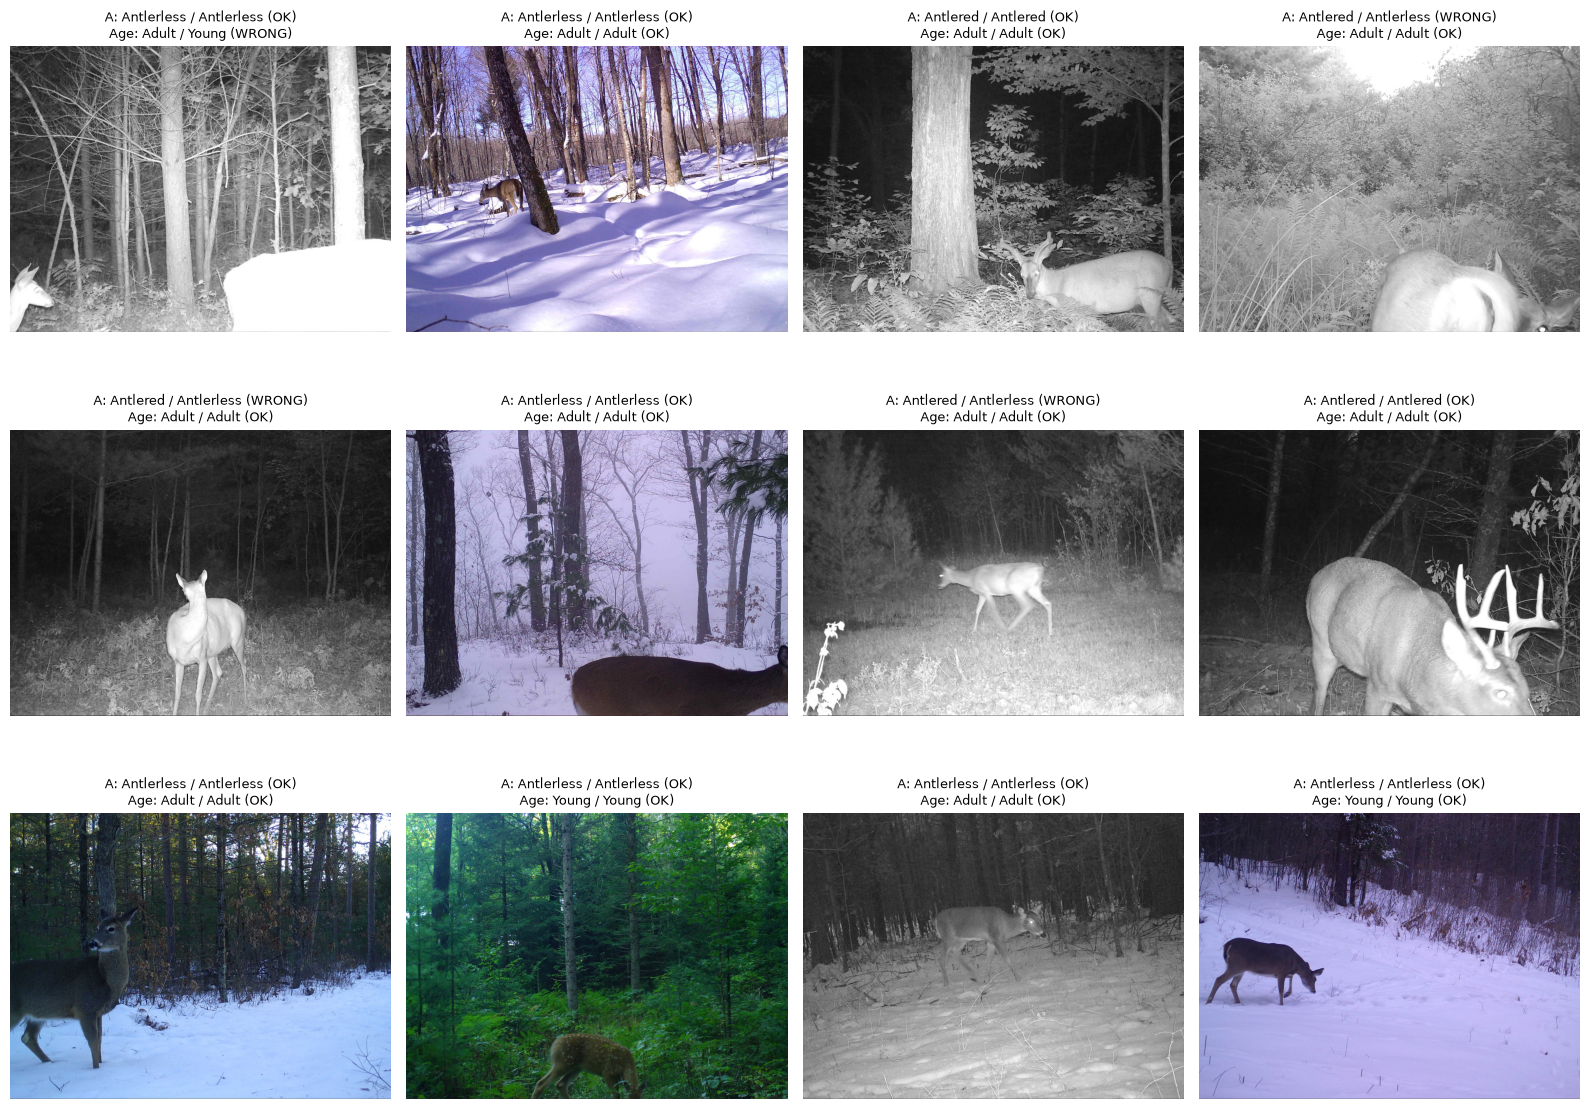

In [47]:
random_rows = df.sample(NUMBER_OF_RANDOM_IMAGES, random_state=None)
results = []
for _, row in random_rows.iterrows():
    result, _ = predict_one(row)
    results.append(result)

results_df = pd.DataFrame(results)
results_df['antler_correct'] = results_df['true_antler'] == results_df['pred_antler']
results_df['age_correct'] = results_df['true_age'] == results_df['pred_age']
print('Antler accuracy:', f"{results_df['antler_correct'].mean():.1%}")
print('Age accuracy:', f"{results_df['age_correct'].mean():.1%}")
display(results_df.drop(columns=['image_path']))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for axis, (_, row) in zip(axes.flat, random_rows.iterrows()):
    result, image = predict_one(row)
    axis.imshow(image)
    axis.axis('off')
    antler_mark = 'OK' if result['true_antler'] == result['pred_antler'] else 'WRONG'
    age_mark = 'OK' if result['true_age'] == result['pred_age'] else 'WRONG'
    axis.set_title(
        f"A: {result['pred_antler']} / {result['true_antler']} ({antler_mark})\n"
        f"Age: {result['pred_age']} / {result['true_age']} ({age_mark})",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## 6. Check a specific image

Replace the filename below with any filename from the CSV.

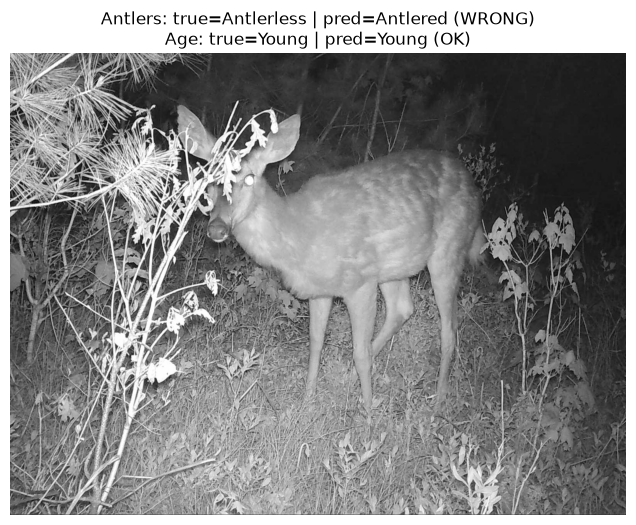

filename              SSWI000000027884533B.jpg
true_antler                         Antlerless
pred_antler                           Antlered
antler_probability                    0.513456
true_age                                 Young
pred_age                                 Young
age_probability                        0.68667


{'filename': 'SSWI000000027884533B.jpg',
 'true_antler': 'Antlerless',
 'pred_antler': 'Antlered',
 'antler_probability': 0.5134561657905579,
 'true_age': 'Young',
 'pred_age': 'Young',
 'age_probability': 0.6866704821586609,
 'image_path': 'd:\\电子教材\\UWM\\Snapshot\\Snapshot_WI-Oh_Deer_Photos\\Deer\\SSWI000000027884533B.jpg'}

In [48]:
filename_to_check = df.iloc[0]['filename']
show_prediction(filename_to_check)